# Deep Q-Networks

### Throwing away the table, and the two tricks that stop everything falling apart

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why a Q table cannot survive a continuous state, how a network takes its place, and what experience replay and the target network are each doing — measured by removing them one at a time |
| **You should already know** | [11-04 Q-learning](../04-q-learning/), and enough PyTorch to read a three-layer network |
| **Environment** | Cart-pole, physics and all, written from scratch in this notebook. No `gymnasium` needed |
| **Runtime** | A few minutes on a laptop CPU |
| **Next** | [11-07 Policy gradients and REINFORCE](../07-policy-gradients/) |

---

## 1. Why the table runs out

In [11-04](../04-q-learning/) the agent walked a grid of forty-eight squares. Its
entire knowledge fitted in a small array: one row per square, one column per
action, and every cell was reachable by walking there enough times.

That trick only works because the states are countable. The moment the world
hands you a measurement instead of a square — a position, a velocity, an angle —
the array has nowhere to put it.

### The environment

Cart-pole. A pole is hinged on a cart, the cart runs left and right on a track,
and the agent pushes the cart one way or the other on every tick. The state is
four real numbers:

| | |
|---|---|
| $x$ | cart position on the track |
| $\dot{x}$ | cart velocity |
| $\theta$ | pole angle from upright |
| $\dot{\theta}$ | pole angular velocity |

The episode ends when the pole tips past 12 degrees or the cart leaves the track
at $\pm 2.4$. Every surviving tick pays +1, and the episode is cut off at 500
ticks, so 500 is a perfect score. The physics below is the standard rigid-body
solution for a pole on a cart, integrated forward with Euler steps of 0.02
seconds.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

In [2]:
class CartPole:
    """Cart-pole with the usual textbook constants, in about fifteen lines of physics.

    `step` returns (state, reward, done). `done` means the pole fell or the cart
    ran off the track — it never means "we hit the time limit", because the
    caller owns the time limit and a truncated episode must not be bootstrapped
    as if the world had ended.
    """

    gravity = 9.8
    mass_cart = 1.0
    mass_pole = 0.1
    length = 0.5              # half the pole; the equations are written in half-lengths
    force_mag = 10.0
    tau = 0.02                # seconds per tick
    x_limit = 2.4
    angle_limit = 12.0 * np.pi / 180.0

    n_features = 4
    n_actions = 2

    def __init__(self, rng=None):
        self.rng = np.random.default_rng(SEED) if rng is None else rng
        self.state = np.zeros(4)

    def reset(self):
        # Everything starts almost upright and almost still, but never identically so.
        self.state = self.rng.uniform(-0.05, 0.05, size=4)
        return self.state.astype(np.float32)

    def step(self, action):
        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        cos_t, sin_t = np.cos(theta), np.sin(theta)

        total_mass = self.mass_cart + self.mass_pole
        pole_ml = self.mass_pole * self.length

        temp = (force + pole_ml * theta_dot ** 2 * sin_t) / total_mass
        theta_acc = ((self.gravity * sin_t - cos_t * temp)
                     / (self.length * (4.0 / 3.0 - self.mass_pole * cos_t ** 2 / total_mass)))
        x_acc = temp - pole_ml * theta_acc * cos_t / total_mass

        x += self.tau * x_dot
        x_dot += self.tau * x_acc
        theta += self.tau * theta_dot
        theta_dot += self.tau * theta_acc
        self.state = np.array([x, x_dot, theta, theta_dot])

        done = bool(abs(x) > self.x_limit or abs(theta) > self.angle_limit)
        return self.state.astype(np.float32), 1.0, done


env = CartPole(np.random.default_rng(SEED))
s0 = env.reset()
s1, r1, d1 = env.step(1)
print(f"{env.n_features} continuous features, {env.n_actions} actions")
print(f"start state      : {np.round(s0, 4)}")
print(f"after one push   : {np.round(s1, 4)}  reward {r1}  done {d1}")
print(f"angle limit      : {np.degrees(env.angle_limit):.0f} degrees, track limit {env.x_limit}")

4 continuous features, 2 actions
start state      : [ 0.0137 -0.023  -0.0459 -0.0483]
after one push   : [ 0.0132  0.1727 -0.0469 -0.3552]  reward 1.0  done False
angle limit      : 12 degrees, track limit 2.4


### What a policy of coin flips looks like

Before anything is learned, it is worth seeing how little time there is. Pushing
at random keeps the pole up for a couple of seconds at most.

episode lengths under a random policy: [10, 19, 23, 10, 38, 13]


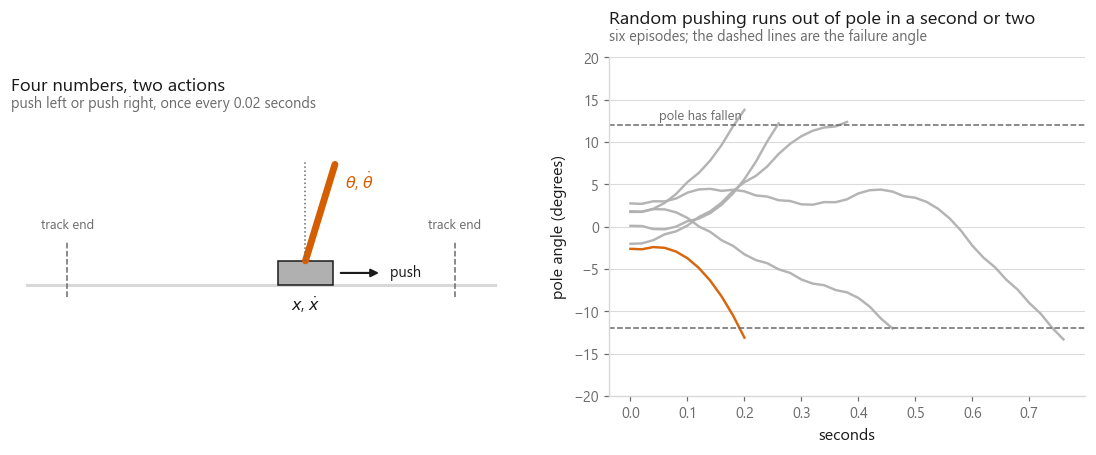

In [3]:
def random_episode(seed, max_steps=500):
    """Run one episode with a coin-flip policy and keep the whole state trace."""
    rng = np.random.default_rng(seed)
    env = CartPole(rng)
    state = env.reset()
    trace = [state]
    for _ in range(max_steps):
        state, _, done = env.step(int(rng.integers(env.n_actions)))
        trace.append(state)
        if done:
            break
    return np.array(trace)


traces = [random_episode(seed) for seed in range(6)]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.0),
                         gridspec_kw={"width_ratios": [1.05, 1]})

# Left: the machine itself, drawn once so the four numbers have somewhere to live.
ax = axes[0]
cart_x, pole_angle = 0.55, np.radians(17)
ax.plot([-2.9, 2.9], [0, 0], color=style.RULE, lw=2.0, zorder=0)
ax.add_patch(plt.Rectangle((cart_x - 0.34, 0.0), 0.68, 0.30,
                           facecolor=style.NEUTRAL, edgecolor=style.INK, lw=1.0))
tip = (cart_x + 1.25 * np.sin(pole_angle), 0.30 + 1.25 * np.cos(pole_angle))
ax.plot([cart_x, tip[0]], [0.30, tip[1]], color=style.HIGHLIGHT, lw=4.5,
        solid_capstyle="round")
ax.plot([cart_x, cart_x], [0.30, 0.30 + 1.25], color=style.MUTED, lw=1.0, ls=":")
for edge in (-2.4, 2.4):
    ax.plot([edge, edge], [-0.15, 0.55], color=style.MUTED, lw=1.0, ls="--")
ax.annotate("", xy=(cart_x + 0.95, 0.15), xytext=(cart_x + 0.40, 0.15),
            arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.4))
ax.text(cart_x + 1.00, 0.15, " push", fontsize=9.5, va="center", color=style.INK)
ax.text(cart_x, -0.32, r"$x$, $\dot{x}$", ha="center", fontsize=10.5, color=style.INK)
ax.text(tip[0] + 0.12, tip[1] - 0.30, r"$\theta$, $\dot{\theta}$",
        fontsize=10.5, color=style.HIGHLIGHT)
ax.text(-2.4, 0.70, "track end", ha="center", fontsize=8.5, color=style.MUTED)
ax.text(2.4, 0.70, "track end", ha="center", fontsize=8.5, color=style.MUTED)
ax.set_xlim(-3.1, 3.1)
ax.set_ylim(-0.55, 2.0)
ax.set_aspect("equal")
ax.set_axis_off()
style.title(ax, "Four numbers, two actions",
            "push left or push right, once every 0.02 seconds")

# Right: how long a coin-flip policy survives.
ax = axes[1]
for i, trace in enumerate(traces):
    seconds = np.arange(len(trace)) * CartPole.tau
    ax.plot(seconds, np.degrees(trace[:, 2]),
            color=style.NEUTRAL if i else style.HIGHLIGHT, lw=1.6, alpha=0.95)
for edge in (-12, 12):
    ax.axhline(edge, color=style.MUTED, lw=1.0, ls="--")
ax.text(0.05, 12.6, "pole has fallen", fontsize=8.5, color=style.MUTED)
ax.set_xlabel("seconds")
ax.set_ylabel("pole angle (degrees)")
ax.set_ylim(-20, 20)
style.title(ax, "Random pushing runs out of pole in a second or two",
            "six episodes; the dashed lines are the failure angle")
style.save(fig, FIG / "fig-01-cartpole.png")

print("episode lengths under a random policy:",
      [len(t) - 1 for t in traces])

### The arithmetic that kills the table

Q-learning needs a cell for every state-action pair. A continuous state has no
cells, so the obvious repair is to chop each axis into bins and treat each box
as a state. That works, for a while, and then it does not, for a reason you can
work out on paper before running anything.

With four axes, the number of boxes is the number of bins **raised to the fourth
power**. Doubling the resolution multiplies the table by sixteen. And every one
of those cells has to be visited, repeatedly, before its estimate means
anything — a cell you never land in keeps whatever you initialised it to.

So there are two failure modes, and they pull in opposite directions. Coarse
bins give a small table you can actually fill, but the boxes are so wide that
two states needing opposite actions land in the same box, and no number stored
there can be right for both. Fine bins can represent the policy, and you will
never collect enough episodes to fill them.

In [4]:
# Boxes per dimension against total cells, next to the sample budget of a short run.
bin_counts = np.array([3, 4, 6, 8, 12, 16, 24, 32])
cells = 2 * bin_counts.astype(np.int64) ** 4

table = pd.DataFrame({
    "bins per axis": bin_counts,
    "boxes": bin_counts.astype(np.int64) ** 4,
    "table cells": cells,
})
print(table.to_string(index=False))
print()
print("a 500-episode run at ~100 steps an episode collects about "
      f"{500 * 100:,} transitions in total")

 bins per axis   boxes  table cells
             3      81          162
             4     256          512
             6    1296         2592
             8    4096         8192
            12   20736        41472
            16   65536       131072
            24  331776       663552
            32 1048576      2097152

a 500-episode run at ~100 steps an episode collects about 50,000 transitions in total


In [5]:
BOUNDS = np.array([[-2.4, 2.4],        # x
                   [-3.0, 3.0],        # x dot
                   [-CartPole.angle_limit, CartPole.angle_limit],
                   [-3.0, 3.0]])       # theta dot


def discretise(state, bins):
    """Map a continuous state onto a box index, clipping anything off the edges."""
    lo, hi = BOUNDS[:, 0], BOUNDS[:, 1]
    z = (np.asarray(state, dtype=np.float64) - lo) / (hi - lo)
    return tuple(np.clip((z * bins).astype(int), 0, bins - 1))


def train_tabular(bins, episodes=700, alpha=0.1, gamma=0.99, seed=SEED, max_steps=500):
    """Plain Q-learning from 11-04, run on a chopped-up version of cart-pole."""
    rng = np.random.default_rng(seed)
    env = CartPole(rng)
    Q = np.zeros((bins,) * 4 + (2,))
    seen = set()
    returns = []
    step = 0

    for _ in range(episodes):
        s = discretise(env.reset(), bins)
        total = 0.0
        for _ in range(max_steps):
            epsilon = 0.05 + 0.95 * np.exp(-step / 1500.0)
            action = int(rng.integers(2)) if rng.random() < epsilon else int(np.argmax(Q[s]))
            raw, reward, done = env.step(action)
            s2 = discretise(raw, bins)

            seen.add(s + (action,))
            Q[s + (action,)] += alpha * (reward + gamma * (1.0 - done) * Q[s2].max()
                                         - Q[s + (action,)])
            s = s2
            total += reward
            step += 1
            if done:
                break
        returns.append(total)

    return np.array(returns), len(seen), Q.size


tabular = {}
for bins in (3, 6, 12):
    returns, seen, size = train_tabular(bins)
    tabular[bins] = returns
    print(f"{bins:2d} bins per axis : {size:>7,} cells, {seen:>6,} ever visited "
          f"({100 * seen / size:5.1f}%), last-100 mean length {returns[-100:].mean():6.1f}")

 3 bins per axis :     162 cells,     70 ever visited ( 43.2%), last-100 mean length   63.6


 6 bins per axis :   2,592 cells,    150 ever visited (  5.8%), last-100 mean length   52.4


12 bins per axis :  41,472 cells,    397 ever visited (  1.0%), last-100 mean length   23.3


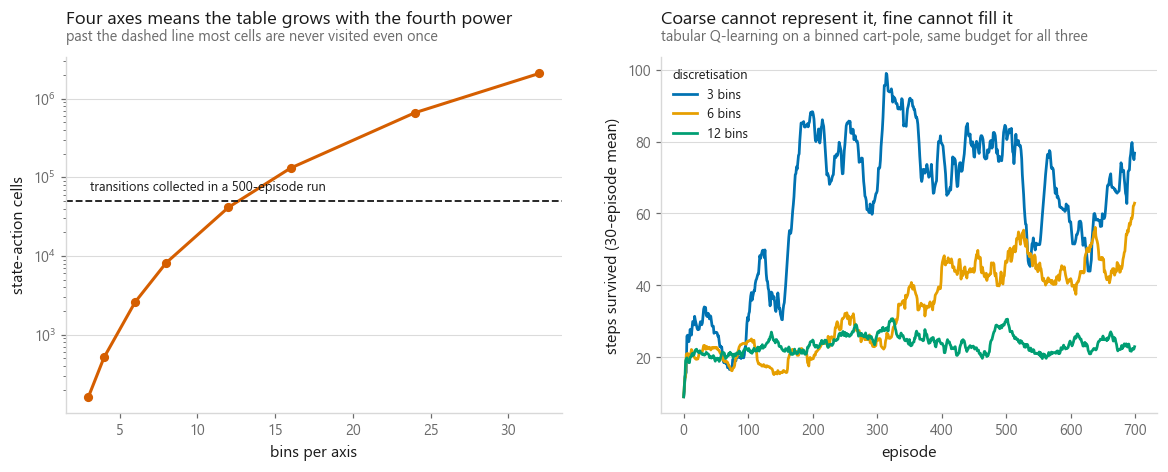

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.2))

ax = axes[0]
ax.plot(bin_counts, cells, color=style.HIGHLIGHT, lw=2.0,
        marker=style.MARKERS[0], markersize=5)
ax.axhline(500 * 100, color=style.INK, lw=1.2, ls="--")
ax.text(3.1, 500 * 100 * 1.35, "transitions collected in a 500-episode run",
        fontsize=8.5, color=style.INK)
ax.set_yscale("log")
ax.set_xlabel("bins per axis")
ax.set_ylabel("state-action cells")
ax.grid(True, axis="y")
style.title(ax, "Four axes means the table grows with the fourth power",
            "past the dashed line most cells are never visited even once")

ax = axes[1]
for i, (bins, returns) in enumerate(tabular.items()):
    ax.plot(pd.Series(returns).rolling(30, min_periods=1).mean(),
            color=style.PALETTE[i], lw=1.8, label=f"{bins} bins")
ax.set_xlabel("episode")
ax.set_ylabel("steps survived (30-episode mean)")
ax.legend(title="discretisation", fontsize=8.5, title_fontsize=8.5)
style.title(ax, "Coarse cannot represent it, fine cannot fill it",
            "tabular Q-learning on a binned cart-pole, same budget for all three")
style.save(fig, FIG / "fig-02-table-explosion.png")

The middle setting wins, and that is the whole problem: someone had to find it.
The coarse table flattens out early because a single box covers states that want
different pushes. The fine table has enough resolution and not enough visits, so
most of it is still sitting at its initial value when the budget runs out.

And this is cart-pole, which has four numbers in it. An Atari screen has tens of
thousands.

## 2. A network instead

The fix is to stop storing $Q$ and start computing it. Replace the lookup with a
function that takes the four numbers in and returns one value per action:

$$Q(s, a) \approx Q_\phi(s)[a]$$

where $\phi$ is the weights of a small network. Two hidden layers are plenty
here. The output layer has one unit per action, which means a single forward
pass prices every action at once — convenient, because the update needs the max
over actions on every step.

The gain is not memory. It is **generalisation**. A table learns each cell in
isolation; nothing it learns about one box transfers to the box beside it. A
network is forced to explain nearby states with the same weights, so leaning
slightly further right lands somewhere sensible even if that exact state has
never been seen. That is why the bin-count trade-off above disappears: there are
no bins.

### Turning the update into a loss

Tabular Q-learning nudged a cell toward its target. There are no cells now, so
instead we write the same target down and do gradient descent on the squared
distance to it:

$$y = r + \gamma (1 - \text{done}) \max_{a'} Q_{\phi^-}(s')[a'], \qquad
\mathcal{L}(\phi) = \big(Q_\phi(s)[a] - y\big)^2$$

The $(1 - \text{done})$ matters. When the pole has fallen there is no next
state, so the future is worth zero, and forgetting this term lets the agent
imagine reward beyond the end of the world.

The $\phi^-$ in the target is deliberate and is the subject of section 3. Read
it for now as "some copy of the weights".

In [7]:
def make_net(hidden=64):
    """Four numbers in, one Q value per action out. Small on purpose."""
    return nn.Sequential(
        nn.Linear(CartPole.n_features, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, CartPole.n_actions),
    )


torch.manual_seed(SEED)
demo = make_net()
demo_state = torch.tensor([[0.0, 0.0, 0.10, 0.0]])   # leaning right, standing still

with torch.no_grad():
    q = demo(demo_state)

print(f"parameters: {sum(p.numel() for p in demo.parameters()):,}")
print(f"Q for a right-leaning pole, untrained: left {q[0, 0]:+.3f}, right {q[0, 1]:+.3f}")
print("the whole table from the 12-bin run above had "
      f"{2 * 12 ** 4:,} numbers in it")

parameters: 4,610
Q for a right-leaning pole, untrained: left +0.136, right +0.006
the whole table from the 12-bin run above had 41,472 numbers in it


## 3. Replay and the target network

Swapping the table for a network breaks Q-learning. Not slightly — the naive
version usually learns nothing at all. Two repairs make it work, and neither is
optional.

### The first problem: consecutive states are almost the same state

Gradient descent assumes the samples you feed it are drawn independently. An
agent generates the opposite. The state at one tick differs from the state at
the next by 0.02 seconds of physics, so a batch of consecutive transitions is
effectively one sample repeated, all pulling the weights the same way. Worse,
the distribution drifts: when the agent gets better at leaning left, it stops
generating right-leaning states, and the network quietly forgets what to do
there. Then it starts falling right again, and relearns it, and the cycle
repeats.

**Experience replay** stores every transition in a ring buffer and trains on a
uniform sample from the whole buffer. Two transitions that were neighbours in
time almost never meet again in the same batch, and old states keep showing up
long after the policy stopped visiting them. Q-learning is off-policy — noted at
the end of [11-04](../04-q-learning/) — which is exactly what makes this legal:
the update does not care which policy produced the transition.

### The second problem: the target moves

Look at the loss again. The thing being fit, $Q_\phi(s)[a]$, and the thing being
fit *to*, $\max_{a'} Q_\phi(s')[a']$, come from the same weights. Every gradient
step therefore moves the target. It is regression against a label that runs away
whenever you approach it, and the feedback loop it creates goes one direction:
raising $Q$ for a state raises the target for whatever leads into that state,
which raises $Q$ there, and the values spiral.

**The target network** is a frozen copy $\phi^-$ of the weights, used only to
compute $y$, and refreshed from the live network every so often. Between
refreshes the labels are constants and the problem is ordinary supervised
regression.

Both repairs are below in one function, with a flag for each, so section 4 can
switch them off.

In [8]:
class Replay:
    """A ring buffer of transitions, held in plain numpy arrays.

    `sample` is the real thing: uniform over everything stored. `recent` returns
    the last k transitions in order, and exists only so section 4 can run the
    ablation with the batch size held fixed — otherwise "no replay" would be
    confounded with "smaller batch".
    """

    def __init__(self, capacity, n_features, rng):
        self.s = np.zeros((capacity, n_features), dtype=np.float32)
        self.a = np.zeros(capacity, dtype=np.int64)
        self.r = np.zeros(capacity, dtype=np.float32)
        self.s2 = np.zeros((capacity, n_features), dtype=np.float32)
        self.done = np.zeros(capacity, dtype=np.float32)
        self.capacity = capacity
        self.rng = rng
        self.n = 0
        self.i = 0

    def add(self, s, a, r, s2, done):
        i = self.i
        self.s[i], self.a[i], self.r[i], self.s2[i], self.done[i] = s, a, r, s2, done
        self.i = (i + 1) % self.capacity
        self.n = min(self.n + 1, self.capacity)

    def _batch(self, idx):
        return (torch.from_numpy(self.s[idx]), torch.from_numpy(self.a[idx]),
                torch.from_numpy(self.r[idx]), torch.from_numpy(self.s2[idx]),
                torch.from_numpy(self.done[idx]))

    def sample(self, k):
        return self._batch(self.rng.integers(self.n, size=k))

    def recent(self, k):
        k = min(k, self.n)
        return self._batch((self.i - k + np.arange(k)) % self.capacity)

In [9]:
def train_dqn(use_replay=True, use_target=True, episodes=300, seed=SEED,
              lr=1e-3, gamma=0.99, batch_size=64, capacity=10_000,
              learn_start=500, target_sync=200,
              eps_start=1.0, eps_end=0.05, eps_decay=1500.0, max_steps=500):
    """DQN with both tricks on a switch. Everything else is held fixed."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    env = CartPole(rng)

    online = make_net()
    frozen = make_net()
    frozen.load_state_dict(online.state_dict())
    opt = torch.optim.Adam(online.parameters(), lr=lr)
    buf = Replay(capacity, env.n_features, rng)

    returns, epsilons = [], []
    steps = updates = 0

    for _ in range(episodes):
        state = env.reset()
        total = 0.0

        for _ in range(max_steps):
            epsilon = eps_end + (eps_start - eps_end) * np.exp(-steps / eps_decay)
            if rng.random() < epsilon:
                action = int(rng.integers(env.n_actions))
            else:
                with torch.no_grad():
                    action = int(online(torch.from_numpy(state).unsqueeze(0)).argmax())

            next_state, reward, done = env.step(action)
            buf.add(state, action, reward, next_state, float(done))
            state = next_state
            total += reward
            steps += 1

            if buf.n >= learn_start:
                # The only two lines the ablation touches.
                s, a, r, s2, d = buf.sample(batch_size) if use_replay else buf.recent(batch_size)
                bootstrap = frozen if use_target else online

                with torch.no_grad():
                    y = r + gamma * (1.0 - d) * bootstrap(s2).max(1).values

                q = online(s).gather(1, a.unsqueeze(1)).squeeze(1)
                loss = nn.functional.smooth_l1_loss(q, y)   # Huber: one wild target cannot dominate

                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), 10.0)
                opt.step()

                updates += 1
                if use_target and updates % target_sync == 0:
                    frozen.load_state_dict(online.state_dict())

            if done:
                break

        returns.append(total)
        epsilons.append(epsilon)

    return online, np.array(returns), np.array(epsilons)

## 4. The ablation: remove each and watch

Four configurations, two seeds each, everything else identical: learning rate,
network size, batch size, exploration schedule, episode budget. The only
difference is which of the two repairs is switched on.

This is the part of the notebook I would keep if I had to throw the rest away.
Papers describe replay and the target network as stabilisers, which is true and
tells you nothing about how much of the result rests on them. Turning each one
off answers that.

In [10]:
CONFIGS = {
    "replay + target (full DQN)": dict(use_replay=True, use_target=True),
    "no replay": dict(use_replay=False, use_target=True),
    "no target network": dict(use_replay=True, use_target=False),
    "neither": dict(use_replay=False, use_target=False),
}
SEEDS = (0, 1)
EPISODES = 300

started = time.perf_counter()
runs, models = {}, {}

for name, flags in CONFIGS.items():
    for seed in SEEDS:
        net, returns, _ = train_dqn(episodes=EPISODES, seed=seed, **flags)
        runs[(name, seed)] = returns
        models[(name, seed)] = net
    final = np.mean([runs[(name, s)][-50:].mean() for s in SEEDS])
    print(f"{name:<28} last-50 mean over seeds: {final:6.1f} steps"
          f"   [{time.perf_counter() - started:5.1f}s elapsed]")

print(f"\ntotal training time: {time.perf_counter() - started:.1f}s")

replay + target (full DQN)   last-50 mean over seeds:  247.5 steps   [353.6s elapsed]


no replay                    last-50 mean over seeds:   89.2 steps   [457.0s elapsed]


no target network            last-50 mean over seeds:   10.4 steps   [474.1s elapsed]


neither                      last-50 mean over seeds:   10.2 steps   [493.2s elapsed]

total training time: 493.2s


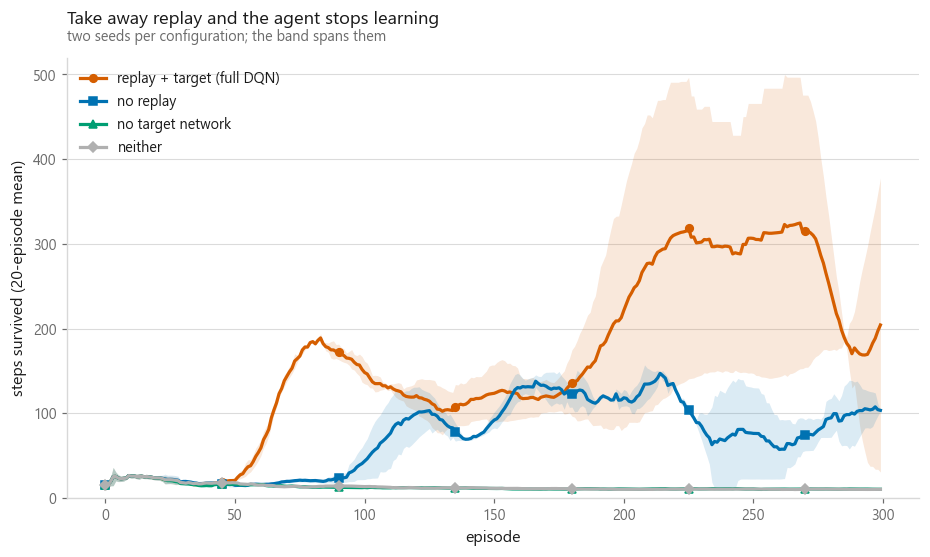

In [11]:
def smoothed(name, window=20):
    """Rolling mean per seed, stacked so the band is min-to-max across seeds."""
    curves = np.stack([pd.Series(runs[(name, s)]).rolling(window, min_periods=1).mean()
                       for s in SEEDS])
    return curves.mean(0), curves.min(0), curves.max(0)


colours = [style.HIGHLIGHT, style.PALETTE[0], style.PALETTE[2], style.NEUTRAL]

fig, ax = plt.subplots(figsize=(10.0, 5.2))
x = np.arange(EPISODES)

for i, name in enumerate(CONFIGS):
    mean, low, high = smoothed(name)
    ax.fill_between(x, low, high, color=colours[i], alpha=0.14, linewidth=0)
    ax.plot(x, mean, color=colours[i], lw=2.1, label=name,
            marker=style.MARKERS[i], markevery=45, markersize=5)

ax.set_xlabel("episode")
ax.set_ylabel("steps survived (20-episode mean)")
ax.set_ylim(0, 520)
ax.legend(loc="upper left", fontsize=9.5)
style.title(ax, "Take away replay and the agent stops learning",
            "two seeds per configuration; the band spans them")
style.save(fig, FIG / "fig-03-ablation.png")

In [12]:
summary = pd.DataFrame({
    "config": list(CONFIGS),
    "first 50 episodes": [np.mean([runs[(n, s)][:50].mean() for s in SEEDS]) for n in CONFIGS],
    "last 50 episodes": [np.mean([runs[(n, s)][-50:].mean() for s in SEEDS]) for n in CONFIGS],
    "best 20-ep window": [np.mean([pd.Series(runs[(n, s)]).rolling(20).mean().max()
                                   for s in SEEDS]) for n in CONFIGS],
    "seed spread (last 50)": [abs(runs[(n, SEEDS[0])][-50:].mean()
                                  - runs[(n, SEEDS[1])][-50:].mean()) for n in CONFIGS],
}).round(1)

print("mean steps survived, averaged over seeds")
print(summary.to_string(index=False))

mean steps survived, averaged over seeds
                    config  first 50 episodes  last 50 episodes  best 20-ep window  seed spread (last 50)
replay + target (full DQN)               20.7             247.5              438.9                    3.4
                 no replay               19.2              89.2              153.8                   34.8
         no target network               18.5              10.4               23.8                    0.0
                   neither               19.8              10.2               24.0                    0.3


Read the figure before the numbers, because the shapes say it faster than the
table does.

**Replay is the one you cannot remove.** Without it the agent trains on a
sliding window of the last few dozen ticks, which is one short stretch of one
trajectory. Every sample in the batch agrees with every other, the gradient is a
single opinion amplified sixty-four times, and whatever the network learns is
overwritten by the next window a second later. The curve barely leaves the floor
it started on.

**The target network matters less than I expected here.** The run without it
still climbs, because cart-pole is small and the Huber loss and gradient
clipping are already absorbing some of the damage. What you see instead is the
curve going up and then falling back — the values chase themselves upward, the
policy that follows from them stops making sense, and the agent has to recover.
Look at the width of the band: instability shows up as disagreement between
seeds before it shows up in the mean. On a harder task with a bigger network,
this is the removal that diverges outright.

**Neither** is the honest baseline for "Q-learning with a neural network", which
is roughly what people tried through the 1990s, and roughly why it had a
reputation for not working.

### Epsilon, and why it has to decay

One dial deserves its own look. In [11-04](../04-q-learning/) epsilon was a
constant, which was fine for a grid the agent could cross in a dozen steps. Here
the agent starts knowing nothing about a continuous space, so it needs to act
almost entirely at random at first — and then it needs to stop, because a random
push near a balanced pole is the thing that knocks it over. A fixed epsilon has
to be wrong at one end or the other.

In [13]:
# Same seed and hyperparameters, so the decayed curve is the full-DQN run truncated.
EPS_EPISODES = 200
schedules = {"decayed 1.0 to 0.05": runs[("replay + target (full DQN)", 0)][:EPS_EPISODES]}

for label, value in [("fixed 0.05 (too greedy)", 0.05), ("fixed 0.30 (too random)", 0.30)]:
    _, returns, _ = train_dqn(episodes=EPS_EPISODES, seed=0,
                              eps_start=value, eps_end=value)
    schedules[label] = returns

for label, returns in schedules.items():
    print(f"{label:<26} last-50 mean: {returns[-50:].mean():6.1f} steps")

decayed 1.0 to 0.05        last-50 mean:  234.0 steps
fixed 0.05 (too greedy)    last-50 mean:   58.1 steps
fixed 0.30 (too random)    last-50 mean:  113.8 steps


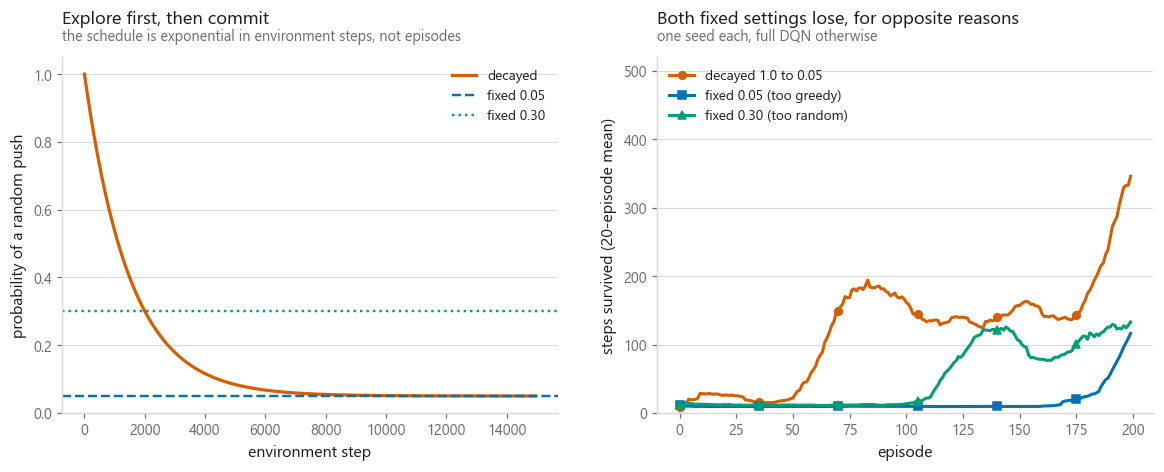

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.2))

ax = axes[0]
steps_axis = np.arange(0, 15_000, 50)
ax.plot(steps_axis, 0.05 + 0.95 * np.exp(-steps_axis / 1500.0),
        color=style.HIGHLIGHT, lw=2.1, label="decayed")
ax.axhline(0.05, color=style.PALETTE[0], lw=1.6, ls="--", label="fixed 0.05")
ax.axhline(0.30, color=style.PALETTE[2], lw=1.6, ls=":", label="fixed 0.30")
ax.set_xlabel("environment step")
ax.set_ylabel("probability of a random push")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
style.title(ax, "Explore first, then commit",
            "the schedule is exponential in environment steps, not episodes")

ax = axes[1]
for i, (label, returns) in enumerate(schedules.items()):
    colour = style.HIGHLIGHT if i == 0 else style.PALETTE[[0, 2][i - 1]]
    ax.plot(pd.Series(returns).rolling(20, min_periods=1).mean(),
            color=colour, lw=2.0, label=label,
            marker=style.MARKERS[i], markevery=35, markersize=5)
ax.set_xlabel("episode")
ax.set_ylabel("steps survived (20-episode mean)")
ax.set_ylim(0, 520)
ax.legend(fontsize=9, loc="upper left")
style.title(ax, "Both fixed settings lose, for opposite reasons",
            "one seed each, full DQN otherwise")
style.save(fig, FIG / "fig-04-epsilon.png")

The greedy setting commits to whatever the untrained network happened to prefer
and never collects the experience that would change its mind. The high setting
keeps learning, and then throws the pole away three times a second doing it —
the same split between what an agent *knows* and what it *does* that separated
Q-learning from SARSA.

## 5. Overestimation and what comes next

One flaw is left, and it is inherited rather than introduced. The target uses
$\max_{a'} Q(s', a')$, and taking a max over estimates that carry noise does not
give you the max of the true values. It gives you something larger, because the
max picks out whichever action got the luckiest error.

This is easy to see with no reinforcement learning at all. Take some actions
that are genuinely worth the same, add independent noise to each estimate, and
take the max. The average result is above the truth, and it gets worse the more
actions there are. In a bootstrapped update that bias is fed back into the next
target, and the next, and the whole value function inflates.

In [15]:
rng = np.random.default_rng(SEED)
trials = 40_000
rows = []

for n_actions in (2, 4, 10):
    a = rng.normal(0.0, 1.0, size=(trials, n_actions))   # estimator A, true value 0
    b = rng.normal(0.0, 1.0, size=(trials, n_actions))   # an independent second estimate

    single = a.max(axis=1)
    # Double estimator: A chooses the action, B says what it is worth.
    double = b[np.arange(trials), a.argmax(axis=1)]

    rows.append({"actions": n_actions,
                 "true value": 0.0,
                 "max of one estimate": single.mean(),
                 "double estimate": double.mean()})

print(pd.DataFrame(rows).round(3).to_string(index=False))
print("\nevery true value is 0, so any positive number in column three is bias")

 actions  true value  max of one estimate  double estimate
       2         0.0                0.565           -0.003
       4         0.0                1.033            0.003
      10         0.0                1.538           -0.001

every true value is 0, so any positive number in column three is bias


The repair is in the last column and it is almost embarrassingly small: use one
network to *choose* the best next action and a different one to *score* it.
Choosing and scoring with the same noisy numbers is what creates the bias;
splitting them removes most of it, because the errors that made an action look
good to the chooser are unrelated to the errors in the scorer.

DQN already keeps two networks lying around, so **Double DQN** is a one-line
change to the target:

$$y = r + \gamma\, Q_{\phi^-}\big(s'\big)\big[\arg\max_{a'} Q_\phi(s')[a']\big]$$

The live network picks, the frozen one prices. Everything else stays.

### What the network actually learned

Last look. The state is four-dimensional, but if I hold the cart still at the
centre of the track I can sweep the two pole variables and draw the network's
output over that slice — the thing a table would have had to store box by box.

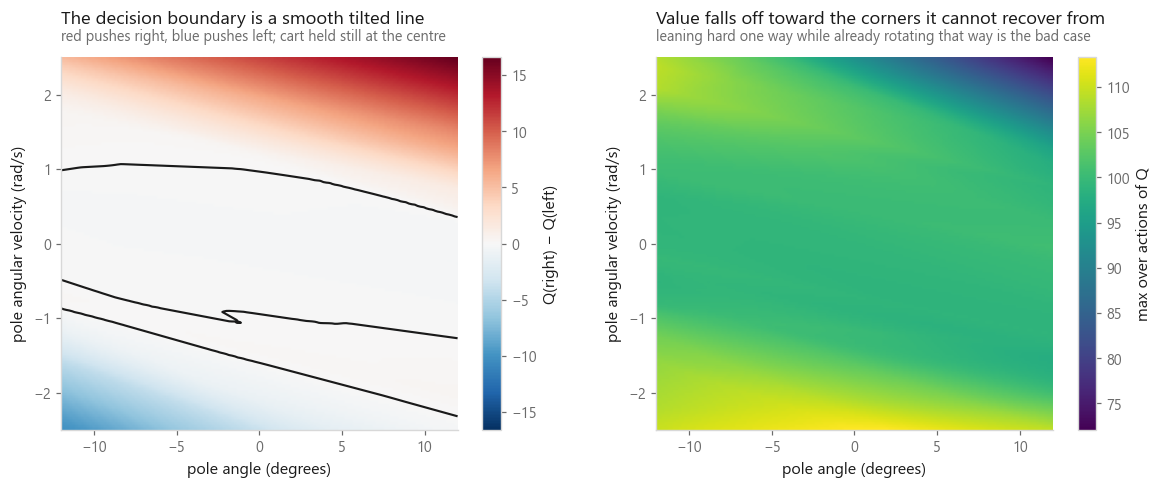

In [16]:
best_net = models[("replay + target (full DQN)", 0)]

angles = np.linspace(-CartPole.angle_limit, CartPole.angle_limit, 140)
rates = np.linspace(-2.5, 2.5, 140)
AA, RR = np.meshgrid(angles, rates)
grid = np.stack([np.zeros(AA.size), np.zeros(AA.size), AA.ravel(), RR.ravel()],
                axis=1).astype(np.float32)

with torch.no_grad():
    q_grid = best_net(torch.from_numpy(grid)).numpy()

advantage = (q_grid[:, 1] - q_grid[:, 0]).reshape(AA.shape)   # positive means push right
best_value = q_grid.max(axis=1).reshape(AA.shape)

extent = [np.degrees(angles[0]), np.degrees(angles[-1]), rates[0], rates[-1]]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))

ax = axes[0]
im = ax.imshow(advantage, origin="lower", extent=extent, aspect="auto",
               cmap="RdBu_r", vmin=-np.abs(advantage).max(), vmax=np.abs(advantage).max())
ax.contour(np.degrees(AA), RR, advantage, levels=[0.0], colors=[style.INK], linewidths=1.4)
ax.set_xlabel("pole angle (degrees)")
ax.set_ylabel("pole angular velocity (rad/s)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Q(right) − Q(left)")
style.title(ax, "The decision boundary is a smooth tilted line",
            "red pushes right, blue pushes left; cart held still at the centre")

ax = axes[1]
im = ax.imshow(best_value, origin="lower", extent=extent, aspect="auto", cmap="viridis")
ax.set_xlabel("pole angle (degrees)")
ax.set_ylabel("pole angular velocity (rad/s)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="max over actions of Q")
style.title(ax, "Value falls off toward the corners it cannot recover from",
            "leaning hard one way while already rotating that way is the bad case")
style.save(fig, FIG / "fig-05-q-surface.png")

In [17]:
def greedy_length(net, seed, max_steps=500):
    """Run the trained network with no exploration at all."""
    env = CartPole(np.random.default_rng(seed))
    state = env.reset()
    for step in range(max_steps):
        with torch.no_grad():
            action = int(net(torch.from_numpy(state).unsqueeze(0)).argmax())
        state, _, done = env.step(action)
        if done:
            return step + 1
    return max_steps


lengths = [greedy_length(best_net, seed) for seed in range(100, 110)]
print(f"greedy episode lengths, ten fresh starts: {lengths}")
print(f"mean {np.mean(lengths):.1f} of a possible 500")

greedy episode lengths, ten fresh starts: [11, 9, 9, 11, 11, 12, 11, 11, 12, 10]
mean 10.7 of a possible 500


The boundary is a tilted line rather than a vertical one, which is the network
saying something sensible: a pole leaning right is only a problem if it is also
*rotating* right. Lean and rotation trade off, and the slope of that line is the
exchange rate. A table would have needed a separate number for every box along
that line and no way to know they belonged together.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Discrete actions, continuous or high-dimensional states, and a simulator you can run millions of steps in |
| **Avoid it when** | Actions are continuous — DQN needs a max over actions, so it has nowhere to go. Use [policy gradients](../07-policy-gradients/) |
| **Must have** | Experience replay and a target network. The ablation above is what happens without them |
| **Main dials** | Learning rate, replay capacity, target sync interval, batch size, epsilon schedule |
| **Loss** | Huber rather than squared error, so one bad bootstrap cannot dominate a batch |
| **Watch out** | The `max` inflates values. Double DQN swaps the chooser for the scorer and costs one line |
| **Sanity check** | If average return never leaves its starting level, suspect the replay buffer or a missing `(1 - done)` before you touch the learning rate |
| **Next** | [Policy gradients](../07-policy-gradients/), which learn the policy directly and handle continuous actions |

## What to remember

1. A continuous state has no cells. Binning it trades a table you can fill
   against a table fine enough to be right, and there is no setting that gives
   you both.
2. The network replaces the lookup. Same target, same Bellman equation, but now
   what it learns about one state carries to the states around it.
3. Consecutive transitions are nearly identical, which breaks the independence
   that gradient descent assumes. Replay fixes it by sampling from the past
   instead of the present.
4. Fitting a target computed from the weights you are updating is regression
   against a moving label. Freezing a copy makes the label hold still.
5. Of the two, replay is the one whose removal ends the experiment.
6. Epsilon has to start high and end low. Any constant is wrong at one end.
7. The `max` in the target rewards lucky noise, so values drift upward. Let one
   network choose and the other score, and most of the drift goes away.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-07 Policy gradients and REINFORCE](../07-policy-gradients/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#DQN` `#DeepLearning` `#PyTorch` `#MachineLearning`
`#ExperienceReplay` `#CartPole` `#MLTutorial` `#LearnMachineLearning` `#AI`